# Práctica 3, Germán Cousillas Martínez

## Apartado 1

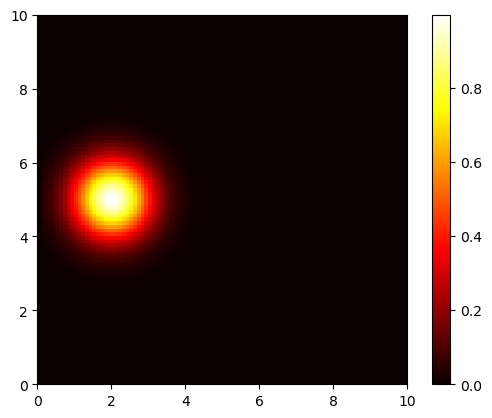

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N=100
L=10
x0=L/5
y0=L/2
sigma=0.75
kappa=15*np.pi
a = L/(N-1)

x = np.linspace(0,L,N)

X, Y = np.meshgrid(x, x)

Psi = np.exp(-(X-x0)**2/(2*sigma**2))*np.exp(-(Y-y0)**2/(2*sigma**2))*np.exp(-1j*kappa*(X-x0))
Psi[0,:]=Psi[:,0]=Psi[-1,:]=Psi[:,-1]=0 # Conds. de contorno de caja

plt.imshow(np.abs(Psi), extent=[0,L,0,L], cmap="hot")
plt.colorbar()
plt.show()

## Apartado 2

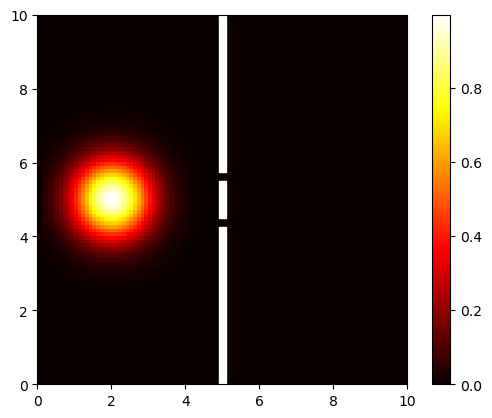

In [2]:
x1 = L/2-0.1
x2 = L/2+0.1
y1=L/2-0.75
y2=L/2-0.5
y3=L/2+0.5
y4=L/2+0.75

def V(x, y):
    if x1 < x and x < x2:
        if y<y1 or (y2<y and y<y3) or y>y4:
            return 200
    return 0

V = np.vectorize(V)

plt.imshow(np.abs(Psi), extent=[0,L,0,L], cmap="hot")
plt.colorbar()
plt.fill_between([x1,x2], [0,0], [y1,y1], color="w")
plt.fill_between([x1,x2], [y2,y2], [y3,y3], color="w")
plt.fill_between([x1,x2], [y4,y4], [L,L], color="w")
plt.show()

## Apartado 3

In [3]:
# Generamos matriz A
h = 2*a**2
r = 1j*h/(2*a**2)

A = np.zeros([(N-2)**2, (N-2)**2], complex)
B = np.zeros([(N-2)**2, (N-2)**2], complex)

# Construimos A y B
for k in range((N-2)**2):
    i=k%(N-2)+1
    j=k//(N-2)+1
    
    A[k,k] = 1 + 4*r + 1j*h/2*V(i*a,j*a)
    B[k,k] = 1 -4*r - 1j*h/2*V(i*a,j*a)
    
    # Si tengo un vecino pegado a la pared entonces soy +/- r
    if i > 1:
        A[k,k-1]=-r
        B[k,k-1]=r
    if i < N-2:
        A[k,k+1]=-r
        B[k,k+1]=r
    if j > 1:
        A[k,k-(N-2)]=-r
        B[k,k-(N-2)]=r
    if j < N-2:
        A[k,k+N-2]=-r
        B[k,k+N-2]=r
          

## Apartado 4

In [4]:
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve


b = np.dot(B, Psi[1:-1,1:-1].reshape((N-2)**2))

Asp = csc_matrix(A)
sol = spsolve(Asp, b)
Psi[1:-1,1:-1]=sol.reshape((N-2,N-2))

## Apartado 5

In [6]:
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve

# Copio todo de nuevo para que la celda sea autocontenida y evitar errores de solapamiento con otras celdas

Psis_data = []

Psi = np.exp(-(X-x0)**2/(2*sigma**2))*np.exp(-(Y-y0)**2/(2*sigma**2))*np.exp(-1j*kappa*(X-x0))
Psi[0,:]=Psi[0,:]=Psi[-1,:]=Psi[:,-1]=0
Asp = csc_matrix(A)

for i in range(100):
    Psis_data.append(Psi.copy())
    b = np.dot(B, Psi[1:-1,1:-1].reshape((N-2)**2))
    sol = spsolve(Asp, b)
    Psi[1:-1,1:-1]=sol.reshape((N-2,N-2))

## Apartado 6

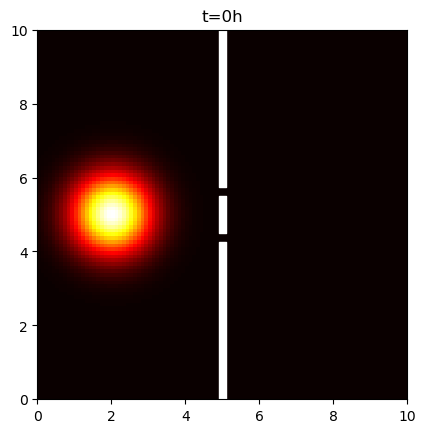

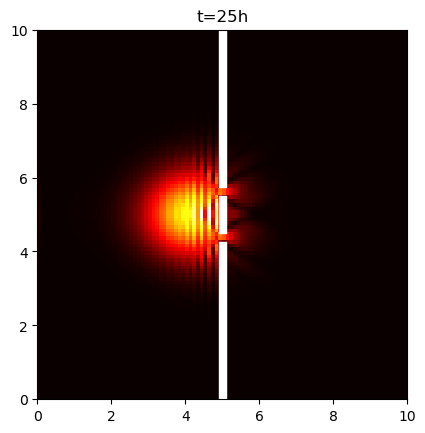

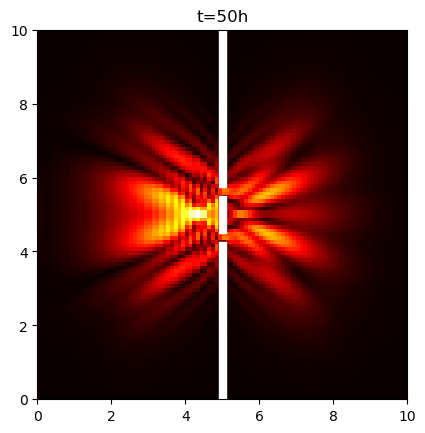

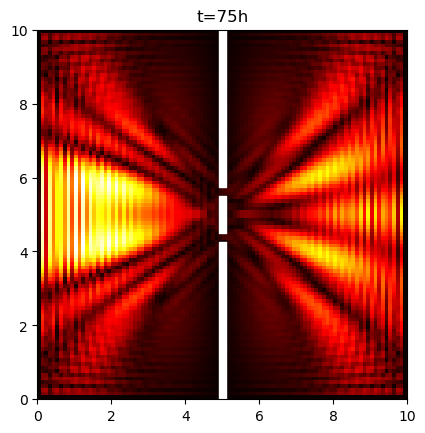

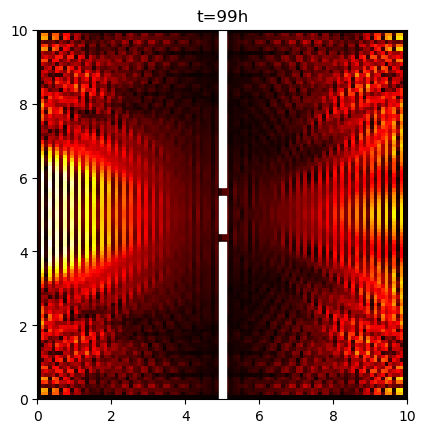

In [7]:
import matplotlib.pyplot as plt

for i in [0,25,50,75,99]:
    plt.title(f"t={i}h")
    plt.imshow(np.abs(Psis_data[i]), extent=[0,L,0,L], cmap="hot")
    plt.fill_between([x1,x2], [0,0], [y1,y1], color="w")
    plt.fill_between([x1,x2], [y2,y2], [y3,y3], color="w")
    plt.fill_between([x1,x2], [y4,y4], [L,L], color="w")
    plt.show()



Parece ser que la función de onda sufre difracción cumplimentando así la hipótesis de De Broglie. Véase que el ejercicio que hemos resuelto es, en esencia, el experimento de la doble rendija de Young para un objeto cuántico representado por una función de onda, como podría ser un electrón.

## Apartado 7

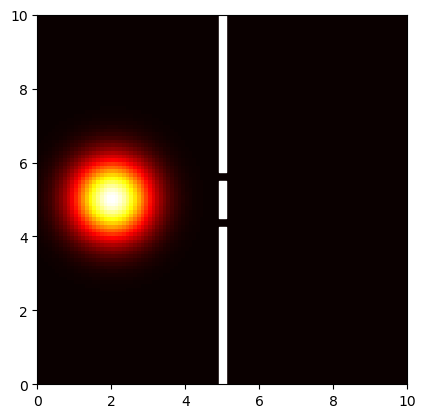

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.core.display import HTML

fig, ax = plt.subplots()
img = ax.imshow(np.abs(Psis_data[0]), extent=[0,L,0,L], cmap="hot")
ax.fill_between([x1,x2], [0,0], [y1,y1], color="w")
ax.fill_between([x1,x2], [y2,y2], [y3,y3], color="w")
ax.fill_between([x1,x2], [y4,y4], [L,L], color="w")

def animacion(frames):
    img.set_data(np.abs(Psis_data[frames]))
    
anim = FuncAnimation(fig, animacion, frames=100,interval=20)
HTML(anim.to_jshtml())